In [41]:
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
df = pd.read_csv("data_fietspalen.csv", sep=";")
df = df[~(df == df.columns).all(axis=1)]
# fix numeric column
df["totaal"] = pd.to_numeric(df["totaal"], errors="coerce")
df["datum"] = pd.to_datetime(df["datum"], errors="coerce")
df = df.dropna(subset=["totaal"])
df = df.dropna(subset=["datum"])
df_locaties = pd.read_csv("data_locaties.csv", sep=";")

/tmp/ipykernel_445250/3666696036.py:1: DtypeWarning: Columns (5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data_fietspalen.csv", sep=";")


In [43]:
print(df)

        code     locatie      datum uur5minuten                   ordening  \
0        VIS    Visserij 2024-01-01     0:00:00  2023-12-31T23:00:00+00:00   
1        VIS    Visserij 2024-01-01     0:05:00  2023-12-31T23:05:00+00:00   
2        VIS    Visserij 2024-01-01     0:10:00  2023-12-31T23:10:00+00:00   
3        VIS    Visserij 2024-01-01     0:15:00  2023-12-31T23:15:00+00:00   
4        VIS    Visserij 2024-01-01     0:20:00  2023-12-31T23:20:00+00:00   
...      ...         ...        ...         ...                        ...   
4926017  GRO  Groendreef 2022-12-31    23:35:00  2022-12-31T22:35:00+00:00   
4926018  GRO  Groendreef 2022-12-31    23:40:00  2022-12-31T22:40:00+00:00   
4926019  GRO  Groendreef 2022-12-31    23:45:00  2022-12-31T22:45:00+00:00   
4926020  GRO  Groendreef 2022-12-31    23:50:00  2022-12-31T22:50:00+00:00   
4926021  GRO  Groendreef 2022-12-31    23:55:00  2022-12-31T22:55:00+00:00   

         totaal tegenrichting hoofdrichting  
0           5.0  

In [44]:
print(df_locaties)

                                             geometry                  naam  \
0   {"coordinates": [3.734989309932452, 51.0646242...           Bataviabrug   
1   {"coordinates": [3.728998679762948, 51.0397150...          Isabellakaai   
2   {"coordinates": [3.720225656341436, 51.0441705...           Bijlokekaai   
3   {"coordinates": [3.740348330134118, 51.0568965...         Dampoort-Zuid   
4   {"coordinates": [3.716310235987854, 51.0687377...       Gaardeniersbrug   
5   {"coordinates": [3.73350908936346, 51.03613180...        Marie Sassepad   
6   {"coordinates": [3.700341375662216, 51.0648424...            Groendreef   
7   {"coordinates": [3.709189838702975, 51.0535479...         Coupure Links   
8   {"coordinates": [3.736291411648564, 51.0396305...          Zuidparklaan   
9   {"coordinates": [3.740000347945883, 51.0538753...      Luc Lemiengrepad   
10  {"coordinates": [3.733398407937317, 51.0357672...     Louisa d'Havébrug   
11  {"coordinates": [3.677120167214546, 51.0427090..

In [45]:
print(df[df["locatie"] == "Visserij"])

        code   locatie      datum uur5minuten                   ordening  \
0        VIS  Visserij 2024-01-01     0:00:00  2023-12-31T23:00:00+00:00   
1        VIS  Visserij 2024-01-01     0:05:00  2023-12-31T23:05:00+00:00   
2        VIS  Visserij 2024-01-01     0:10:00  2023-12-31T23:10:00+00:00   
3        VIS  Visserij 2024-01-01     0:15:00  2023-12-31T23:15:00+00:00   
4        VIS  Visserij 2024-01-01     0:20:00  2023-12-31T23:20:00+00:00   
...      ...       ...        ...         ...                        ...   
4377753  VIS  Visserij 2023-12-31    23:35:00  2023-12-31T22:35:00+00:00   
4377754  VIS  Visserij 2023-12-31    23:40:00  2023-12-31T22:40:00+00:00   
4377755  VIS  Visserij 2023-12-31    23:45:00  2023-12-31T22:45:00+00:00   
4377756  VIS  Visserij 2023-12-31    23:50:00  2023-12-31T22:50:00+00:00   
4377757  VIS  Visserij 2023-12-31    23:55:00  2023-12-31T22:55:00+00:00   

         totaal tegenrichting hoofdrichting  
0           5.0             2            

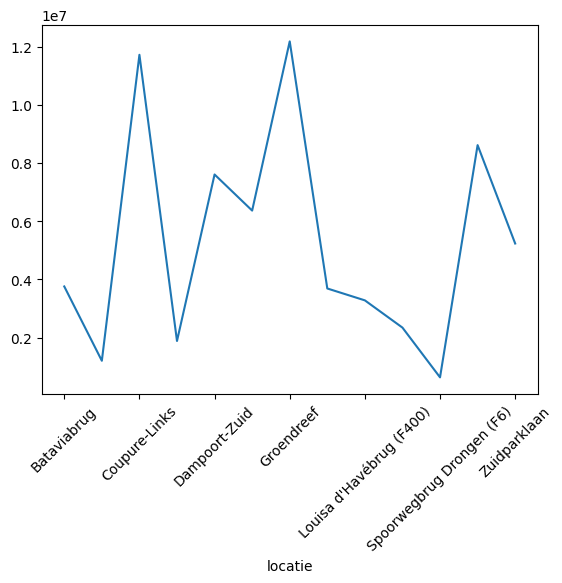

In [46]:
df.groupby("locatie")["totaal"].sum().plot(rot=45)
plt.show()

In [47]:
print(df["locatie"].unique())

['Visserij' 'Spoorwegbrug Drongen (F6)' 'Zuidparklaan' 'Groendreef'
 "Louisa d'Havébrug (F400)" 'Bijlokekaai' 'Gaardeniersbrug' 'Bataviabrug'
 'Dampoort-Zuid' 'Marie Sassepad (F400)' 'Dampoort-Noord' 'Isabellakaai'
 'Coupure-Links']


In [ ]:
print(df.groupby(pd.Grouper(key="datum", freq="YE"))["totaal"].sum())